# Project Overview
Given the dataset regression.csv, create a predictive model for the target variable y defined by: y = count / max(count) import pandas as pd ; df = pd.read_csv('regression.csv') ; df["y"] = df["count"] / df["count"].max()

- To get an understanding of the periodic patterns of the data, have a look at the count variable per hour during a week.
- Since the dataset is a time-ordered event log (hourly demand), use a time-sensitive cross-validation splitter to evaluate the model.

\begin{equation}
    y = \frac{\text{count}}{\max(\text{count})}
\end{equation}

# Import Libraries

In [ ]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit


# Get Data

In [119]:
df = pd.read_csv('regression.csv')

In [120]:
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


In [121]:
df["y"] = df["count"] / df["count"].max()

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  object 
 1   year        17379 non-null  int64  
 2   month       17379 non-null  int64  
 3   hour        17379 non-null  int64  
 4   holiday     17379 non-null  bool   
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  bool   
 7   weather     17379 non-null  object 
 8   temp        17379 non-null  float64
 9   feel_temp   17379 non-null  float64
 10  humidity    17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  count       17379 non-null  int64  
 13  y           17379 non-null  float64
dtypes: bool(2), float64(5), int64(5), object(2)
memory usage: 1.6+ MB


In [123]:
df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count,y
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16,0.016377
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40,0.040942
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32,0.032753
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13,0.013306
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1,0.001024


<Axes: >

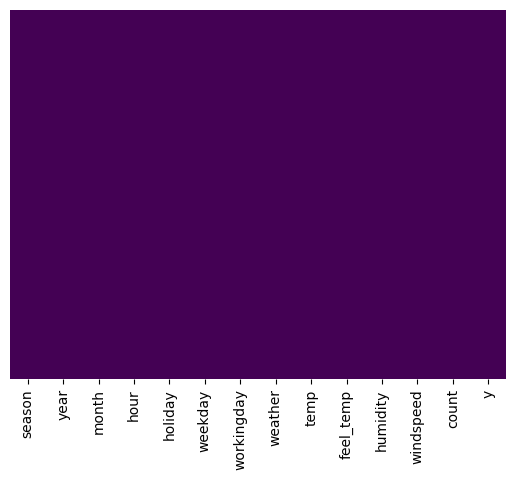

In [124]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

# EDA

<Axes: >

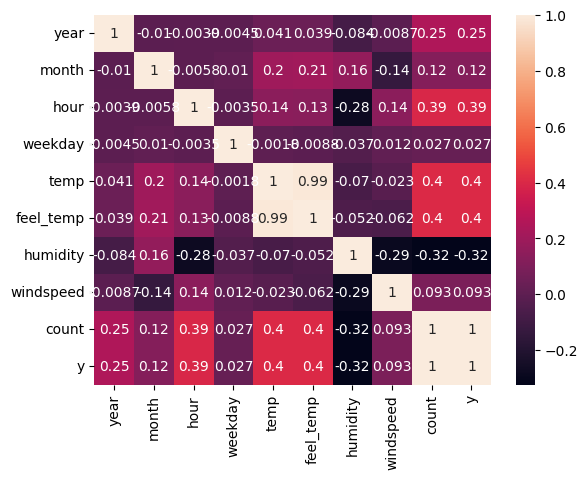

In [125]:
# Seleccionar solo las columnas numéricas
numerical_df = df.select_dtypes(include='number')
# Mostrar la matriz de correlación de las columnas numéricas de 'tips'
correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix,annot=True)

In [126]:
df.pivot_table(values='y',index='month',columns='year')

year,0,1
month,,
1,0.056814,0.133632
2,0.076040,0.152551
3,0.089798,0.227128
4,0.135053,0.248364
5,0.186853,0.269457
6,0.204015,0.288340
7,0.194447,0.280108
8,0.191394,0.295098
9,0.181893,0.310720


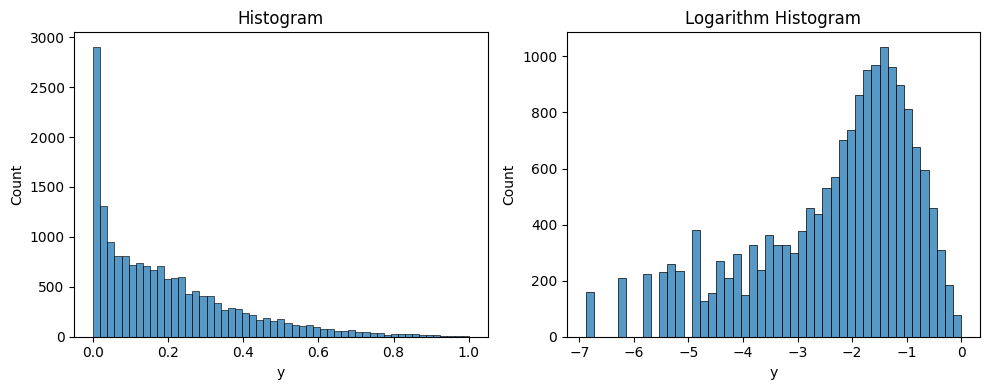

In [127]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['y'], ax=axs[0])
axs[0].set_title('Histogram')

sns.histplot(np.log(df['y']), ax=axs[1])
axs[1].set_title('Logarithm Histogram')

plt.tight_layout()
plt.show()

*El histograma de la distribución de y es asimétrica, por lo cual se grafíca también la distribución logarítmica. Se observa que la distribución logarítmica se asemeja a una distribución normal. Por esta razón a la hora de implementar un modelo se podría utilizar el logaritmo de los valores y.*

# To get an understanding of the periodic patterns of the data, have a look at the count variable per hour during a week.

## Suma

In [128]:
df.groupby(by=['weekday','hour']).sum()['count'].unstack()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,9775,8053,6286,3239,955,852,1493,3476,8805,16437,...,38181,37163,37317,33471,28626,23675,17643,13403,9883,6499
1,3571,1800,1021,496,567,2252,8930,25848,42868,22718,...,20041,21046,29583,52249,50060,35836,25176,18152,12039,6802
2,2790,1254,687,382,508,2470,10863,30569,48122,24118,...,17510,19438,29817,56605,53827,36808,26332,19368,13757,7922
3,3594,1595,797,484,477,2678,11212,31614,50786,24807,...,17737,18854,28388,53367,50885,36823,26436,20051,14800,8625
4,4045,1774,934,497,528,2669,11066,31388,50323,24810,...,18289,20237,29775,54844,52218,37279,27967,20580,15313,10062
5,5453,2571,1325,673,589,2486,9363,26450,48077,26935,...,23854,26256,34423,51211,43783,31415,22186,17667,15295,11982
6,9902,7117,5302,2403,804,854,2205,4826,12020,19613,...,40040,40155,38445,35113,30373,24953,18810,16224,14525,12049


In [129]:
pivot_sum = df.pivot_table(values='count',index='weekday',columns='hour',aggfunc='sum')
pivot_sum

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,9775,8053,6286,3239,955,852,1493,3476,8805,16437,...,38181,37163,37317,33471,28626,23675,17643,13403,9883,6499
1,3571,1800,1021,496,567,2252,8930,25848,42868,22718,...,20041,21046,29583,52249,50060,35836,25176,18152,12039,6802
2,2790,1254,687,382,508,2470,10863,30569,48122,24118,...,17510,19438,29817,56605,53827,36808,26332,19368,13757,7922
3,3594,1595,797,484,477,2678,11212,31614,50786,24807,...,17737,18854,28388,53367,50885,36823,26436,20051,14800,8625
4,4045,1774,934,497,528,2669,11066,31388,50323,24810,...,18289,20237,29775,54844,52218,37279,27967,20580,15313,10062
5,5453,2571,1325,673,589,2486,9363,26450,48077,26935,...,23854,26256,34423,51211,43783,31415,22186,17667,15295,11982
6,9902,7117,5302,2403,804,854,2205,4826,12020,19613,...,40040,40155,38445,35113,30373,24953,18810,16224,14525,12049


## Mean

In [130]:
pivot = df.pivot_table(index='weekday', columns='hour', values='count', aggfunc='mean')
pivot

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,93.990385,77.432692,61.627451,31.144231,9.362745,8.693878,14.495146,33.104762,83.857143,156.542857,...,363.628571,353.933333,355.400000,318.771429,272.628571,225.476190,168.028571,127.647619,94.123810,61.895238
1,34.009524,17.307692,10.313131,5.113402,5.785714,21.653846,85.865385,248.538462,412.192308,218.442308,...,192.701923,202.365385,284.451923,502.394231,481.346154,344.576923,242.076923,174.538462,115.759615,65.403846
2,27.623762,12.540000,6.801980,4.152174,5.131313,24.455446,106.500000,299.696078,471.784314,236.450980,...,168.365385,186.903846,286.701923,544.278846,517.567308,353.923077,253.192308,186.230769,132.278846,76.173077
3,34.557692,15.336538,7.813725,4.888889,4.968750,25.750000,107.807692,303.980769,488.326923,238.528846,...,170.548077,181.288462,272.961538,513.144231,494.029126,357.504854,256.660194,194.669903,143.689320,83.737864
4,39.271845,17.223301,9.156863,5.071429,5.280000,25.912621,107.436893,304.737864,488.572816,240.873786,...,177.563107,196.475728,286.298077,527.346154,502.096154,358.451923,268.913462,197.884615,147.240385,96.750000
5,52.432692,24.721154,12.740385,6.598039,6.072165,23.903846,90.028846,254.326923,462.278846,258.990385,...,229.365385,252.461538,330.990385,492.413462,420.990385,302.067308,213.326923,169.875000,147.067308,115.211538
6,94.304762,67.780952,50.495238,22.885714,7.657143,8.291262,21.000000,45.961905,114.476190,186.790476,...,381.333333,382.428571,366.142857,334.409524,292.048077,239.932692,180.865385,156.000000,139.663462,115.855769


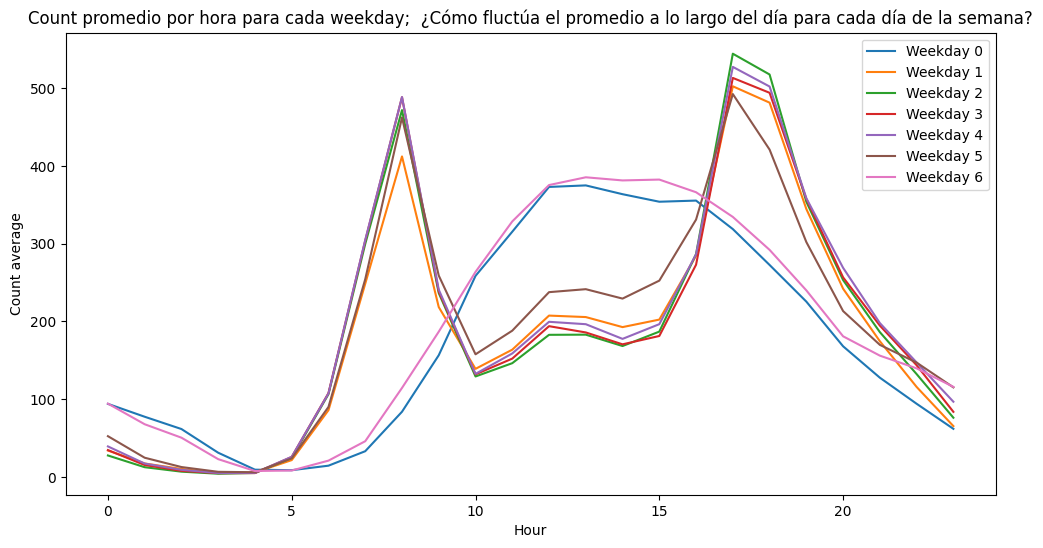

In [131]:
plt.figure(figsize=(12,6))
for weekday in pivot.index:
    plt.plot(pivot.columns, pivot.loc[weekday], label=f'Weekday {weekday}')

plt.legend()
plt.xlabel('Hour')
plt.ylabel('Count average')
plt.title('Count promedio por hora para cada weekday;  ¿Cómo fluctúa el promedio a lo largo del día para cada día de la semana?')
plt.show()

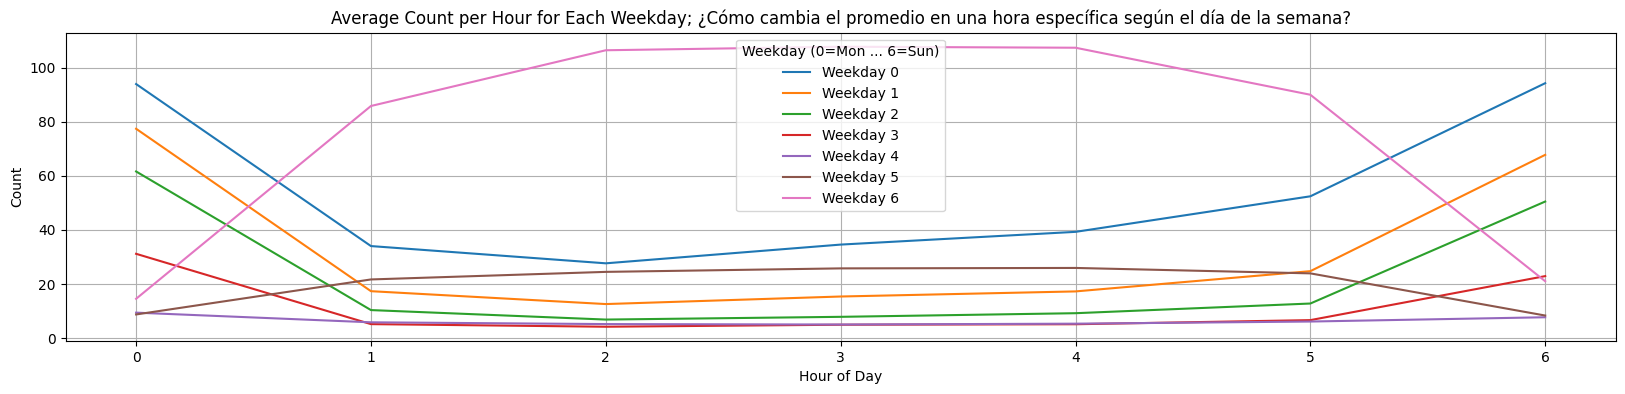

In [114]:
plt.figure(figsize=(20,4))
for wd in range(7):
    plt.plot(pivot.index, pivot[wd], label=f'Weekday {wd}')

plt.title('Average Count per Hour for Each Weekday; ¿Cómo cambia el promedio en una hora específica según el día de la semana?')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.legend(title='Weekday (0=Mon ... 6=Sun)')
plt.grid(True)
plt.show()

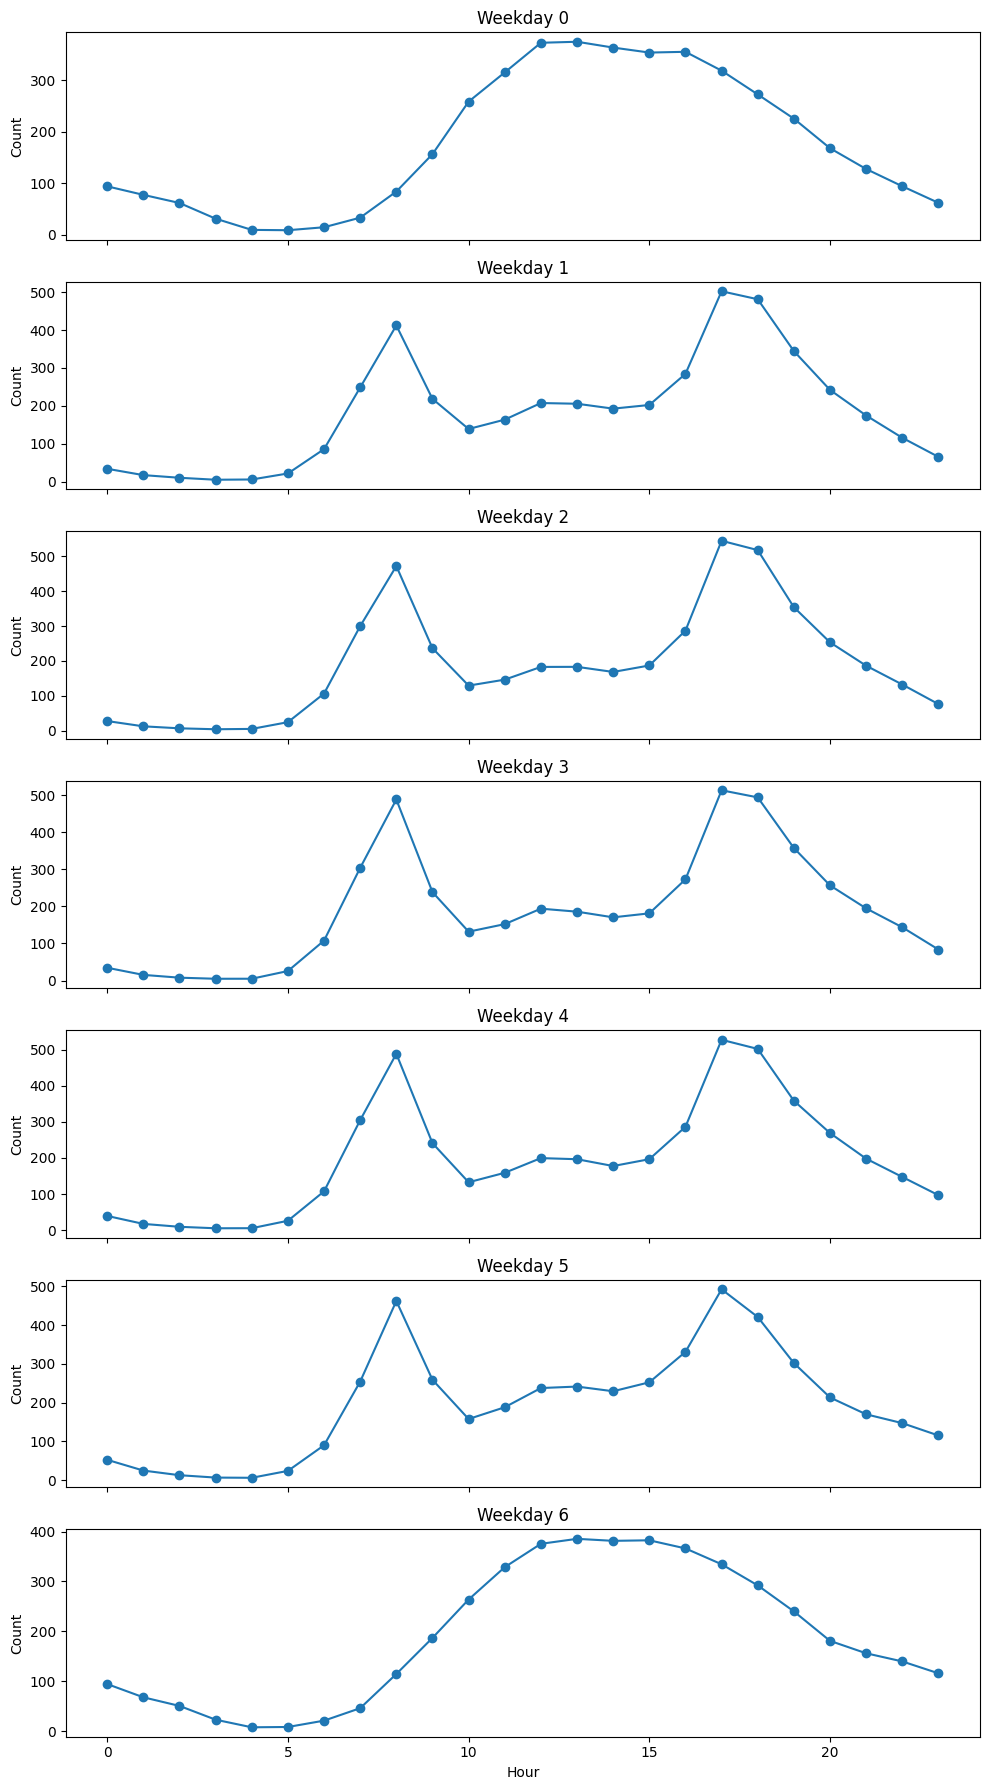

In [117]:
weekday_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6"
}

fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10,18), sharex=True)

for i, weekday in enumerate(pivot.index):
    axes[i].plot(pivot.columns, pivot.loc[weekday], marker="o")
    axes[i].set_title(f"Weekday {weekday_map.get(weekday, weekday)}")
    axes[i].set_ylabel("Count")
    
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

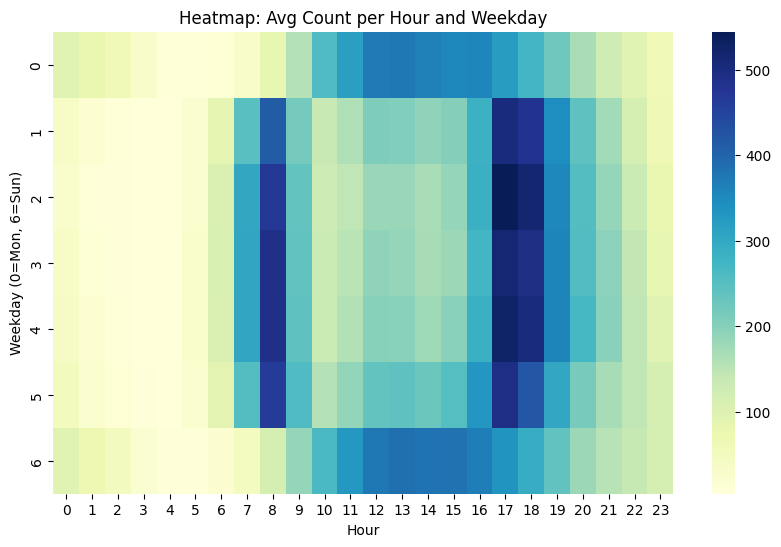

In [39]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.title('Heatmap: Avg Count per Hour and Weekday')
plt.xlabel('Hour')
plt.ylabel('Weekday (0=Mon, 6=Sun)')
plt.show()

Text(0.5, 0, '(Día de la semana)')

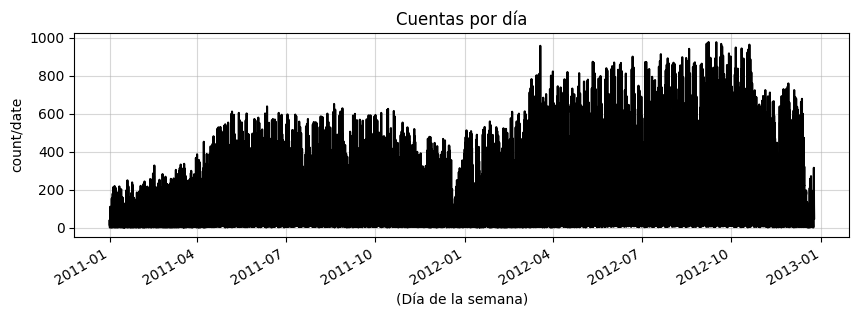

In [93]:
# Ploteo el conteo por dia y por hora. Como no me gusta ver valores medios solamente, agrego las desviaciones standard en cada punto
# (0,0) es: día de la semana 0 y hora 0. Y así sucesivamente. 0 y 6 parecen Domingo y Sábado, respectivamente.
fig, ax = plt.subplots(figsize=(10,3), dpi=100)
mean = df.groupby(['date'])['count'].mean()
std = df.groupby(['date'])['count'].std()

mean.plot(yerr=std, color='black', ecolor='gray')
plt.grid(alpha=0.5)
plt.title('Cuentas por día')
plt.ylabel('count/date')
plt.xlabel('(Día de la semana)')

Text(0.5, 0, '(Día de la semana, Hora del día)')

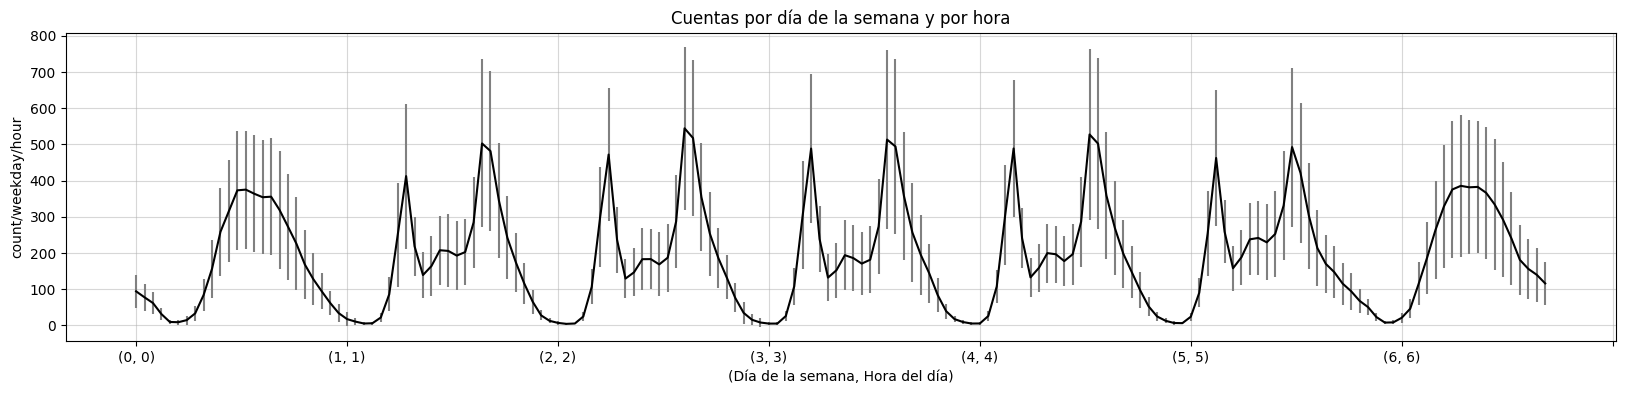

In [104]:
# Ploteo el conteo por dia y por hora. Como no me gusta ver valores medios solamente, agrego las desviaciones standard en cada punto
# (0,0) es: día de la semana 0 y hora 0. Y así sucesivamente. 0 y 6 parecen Domingo y Sábado, respectivamente.
fig, ax = plt.subplots(figsize=(20,4), dpi=100)
mean = df.groupby(['weekday','hour'])['count'].mean()
std = df.groupby(['weekday','hour'])['count'].std()

mean.plot(yerr=std, color='black', ecolor='gray')
plt.grid(alpha=0.5)
plt.title('Cuentas por día de la semana y por hora')
plt.ylabel('count/weekday/hour')
plt.xlabel('(Día de la semana, Hora del día)')

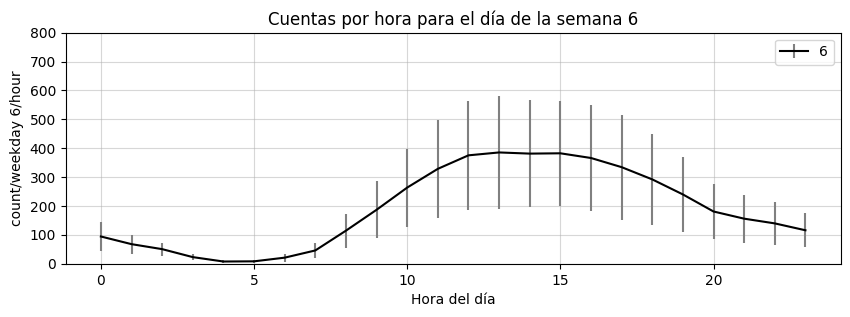

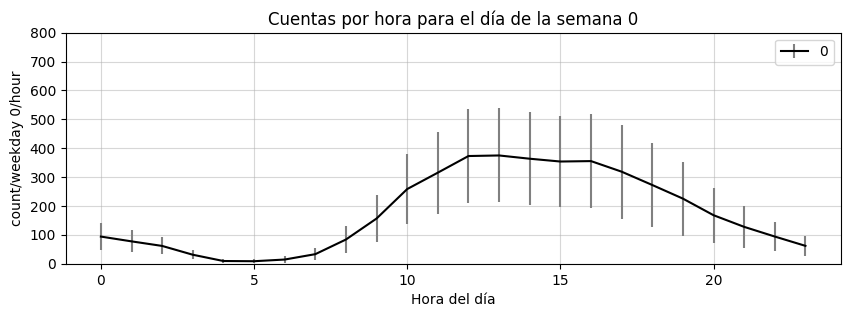

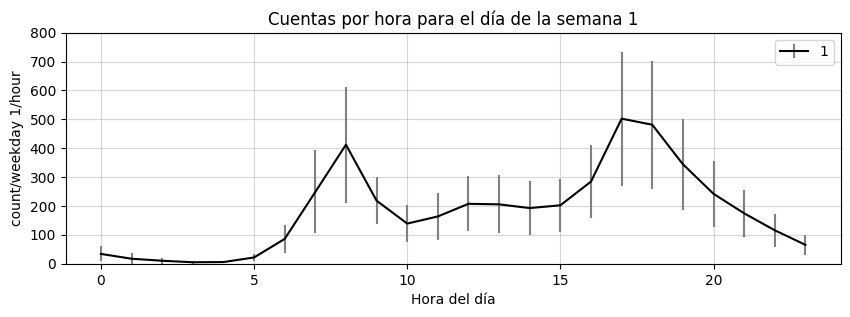

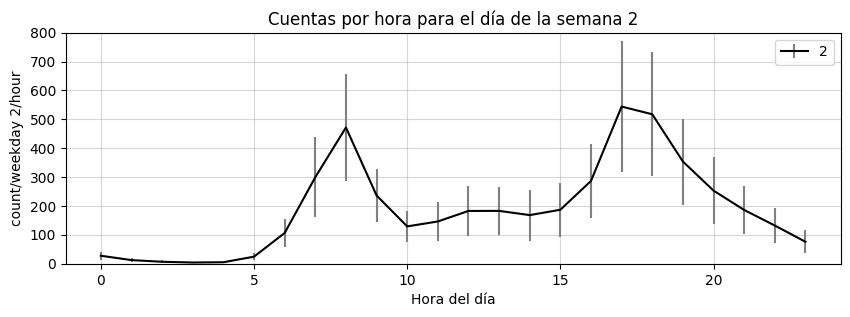

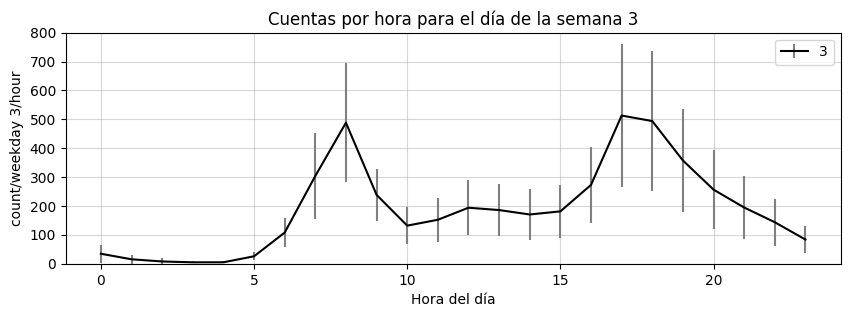

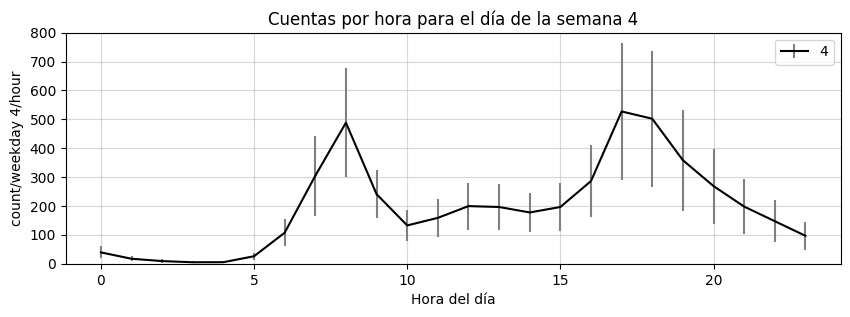

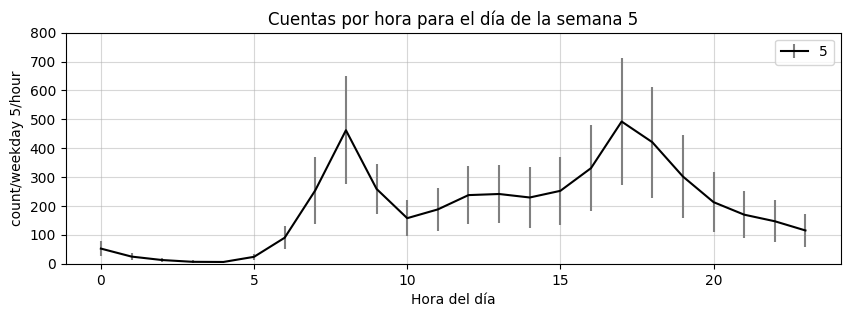

In [105]:
#
for weekd in df['weekday'].unique():
    cond = (df['weekday'] == weekd)
    mean = df[cond].groupby(['hour'])['count'].mean()
    std = df[cond].groupby(['hour'])['count'].std()
    fig, ax = plt.subplots(figsize=(10,3), dpi=100)
    mean.plot(yerr=std, label=weekd, color='black', ecolor='gray' , ax=ax)
    plt.ylim(0,800)
    plt.grid(alpha=0.5)
    plt.legend()
    plt.title(f'Cuentas por hora para el día de la semana {weekd}')
    plt.ylabel(f'count/weekday {weekd}/hour')
    plt.xlabel('Hora del día')    
    plt.show()


# Categorical Features

## Season

<Axes: xlabel='season', ylabel='count'>

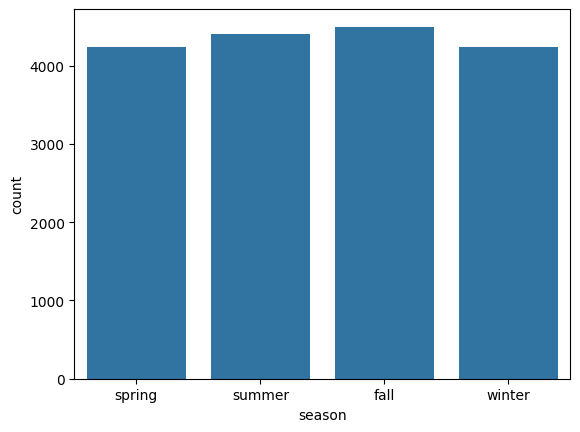

In [52]:
sns.countplot(x='season',data=df)

In [132]:
# Calcular los valores absolutos
season_cant = df['season'].value_counts()
# Calcular los porcentajes
season_perc = 100 * season_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': season_cant, 'Porcentaje': season_perc})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

        Cantidad  Porcentaje
season                      
fall        4496       25.87
summer      4409       25.37
spring      4242       24.41
winter      4232       24.35


## Weather

<Axes: xlabel='weather', ylabel='count'>

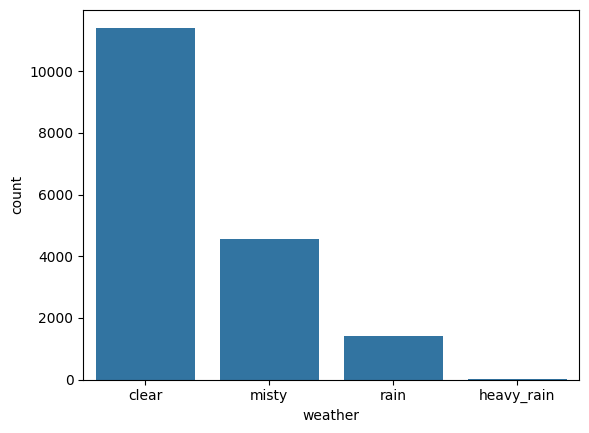

In [53]:
sns.countplot(x='weather',data=df)

In [133]:
# Calcular los valores absolutos
weather_cant = df['weather'].value_counts()
# Calcular los porcentajes
weather_perc = 100 * weather_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': weather_cant, 'Porcentaje': weather_perc})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

            Cantidad  Porcentaje
weather                         
clear          11413       65.67
misty           4544       26.15
rain            1419        8.17
heavy_rain         3        0.02


## Elimino heavy_rain porque tiene muy pocos registros

In [134]:
print(df.shape)
df = df[~(df['weather'] == 'heavy_rain')]
print(df.shape)

(17379, 14)
(17376, 14)


## Data Transformation

In [62]:
cat_feats = ['season','weather']
cat_feats

['season', 'weather']

In [63]:
# A df le agregamos al final columnas que son los valores que vienen en las columnas categóricas del original, y les ponemos 0 o 1
final_data = pd.get_dummies(df,columns=cat_feats,drop_first=True)
     #drop_first=True: De cada variable categórica elimina la primera categoría (evita variables dummies redundantes).
final_data.head()

,holiday,weekday,workingday,temp,feel_temp,humidity,windspeed,count,y,date,season_spring,season_summer,season_winter,weather_heavy_rain,weather_misty,weather_rain
0,False,6,False,9.84,14.395,0.81,0.0,16,0.016377,2011-01-01 00:00:00,True,False,False,False,False,False
1,False,6,False,9.02,13.635,0.80,0.0,40,0.040942,2011-01-01 01:00:00,True,False,False,False,False,False
2,False,6,False,9.02,13.635,0.80,0.0,32,0.032753,2011-01-01 02:00:00,True,False,False,False,False,False
3,False,6,False,9.84,14.395,0.75,0.0,13,0.013306,2011-01-01 03:00:00,True,False,False,False,False,False
4,False,6,False,9.84,14.395,0.75,0.0,1,0.001024,2011-01-01 04:00:00,True,False,False,False,False,False


# Training a Model

## Split

In [147]:
#Genero un spliter para dividir los datos. Los parámetros los elegí a lo largo de sucesivas pruebas.
timeSplits = TimeSeriesSplit(max_train_size=2000, 
                             n_splits=5, 
                             test_size=400,
                             gap=48)

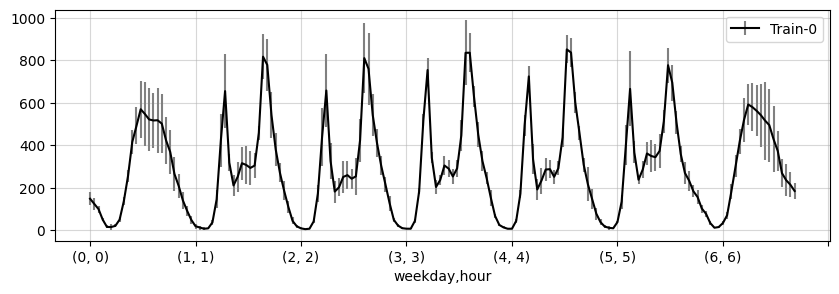

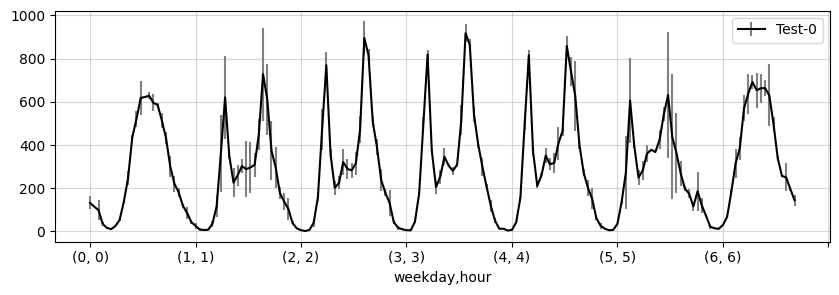

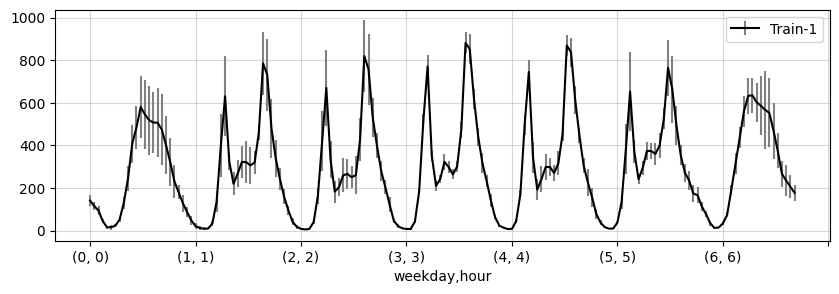

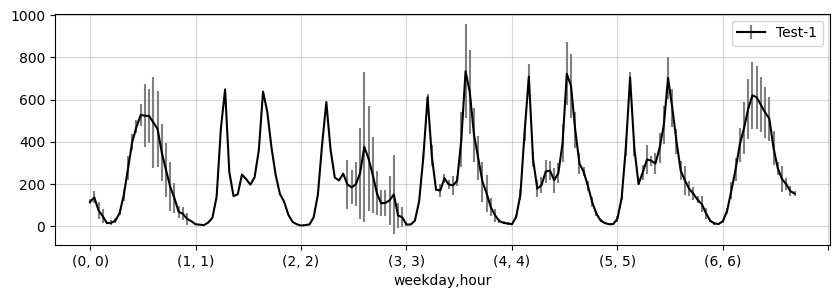

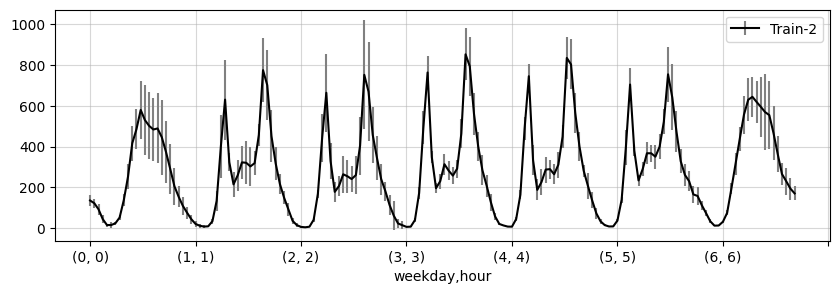

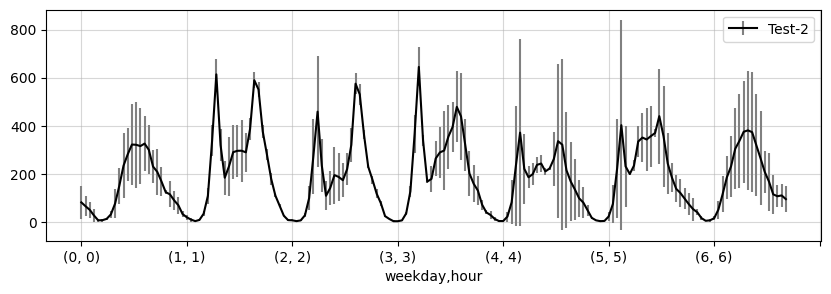

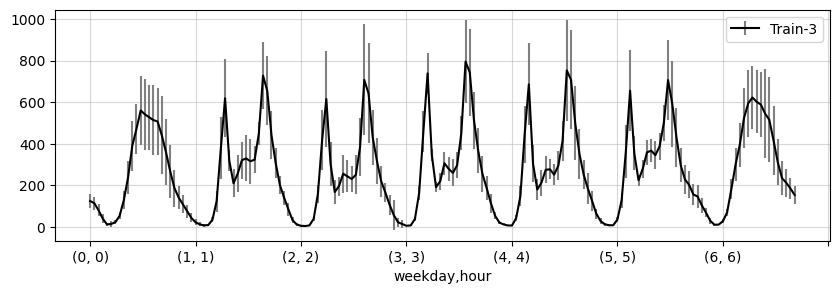

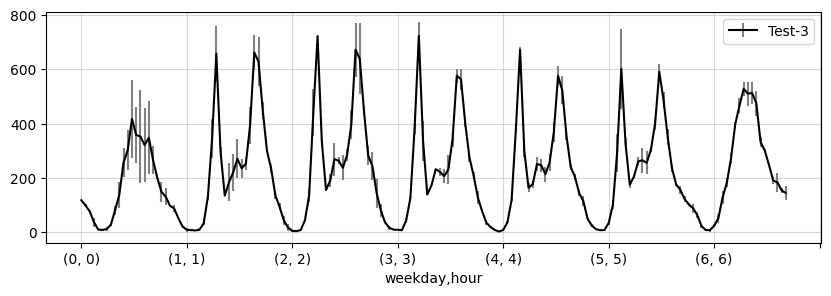

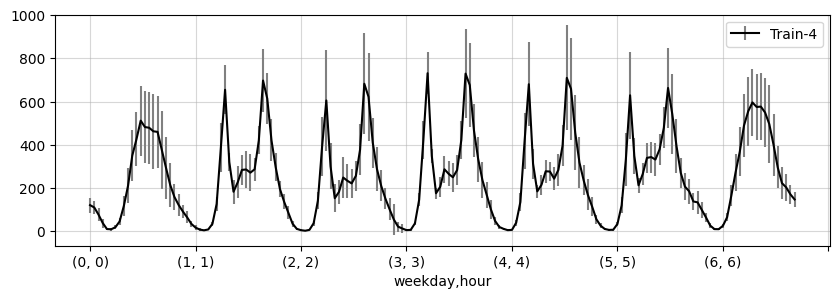

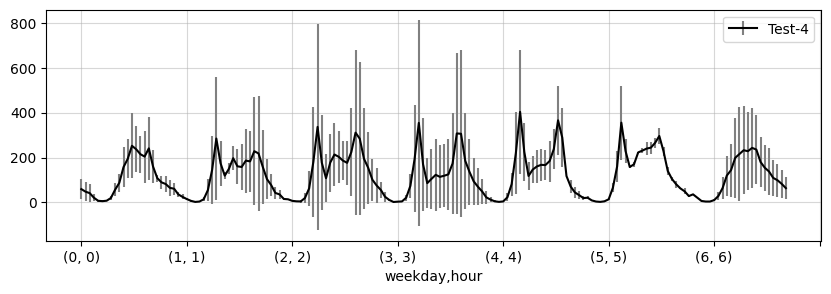

In [148]:
# Como tratandose de series temporales tengo una necesidad imperiosa de verlas gráficamente, muestro los plots de los 5 splits de 
# train y test. De paso, mirando la dispersión, me puede dar una idea de donde puede llegar a dar mejor y peor las métricas resultantes

j=0
for joint in list(timeSplits.split(df)):
    fig, ax = plt.subplots(figsize=(10,3), dpi=100)
    mean = df.iloc[joint[0]].groupby(['weekday','hour'])['count'].mean()
    std = df.iloc[joint[0]].groupby(['weekday','hour'])['count'].std()
    mean.plot(yerr=std, color='black', ecolor='gray', label='Train-'+str(j))
    plt.legend()
    plt.grid(alpha=0.5)
    fig, ax = plt.subplots(figsize=(10,3), dpi=100)
    mean = df.iloc[joint[1]].groupby(['weekday','hour'])['count'].mean()
    std = df.iloc[joint[1]].groupby(['weekday','hour'])['count'].std()
    mean.plot(yerr=std.fillna(0), color='black', ecolor='gray' ,label='Test-'+str(j))
    plt.legend()
    plt.grid(alpha=0.5)
    j+=1
    


# HistGradientBoostingRegressor Model

In [150]:
# Elijo X como la matriz de features e y como target, referido al número máximo de cuentas.
X = df.drop(['count'], axis=1)
y = df['count'] / df['count'].max()

In [159]:
# Elijo algún modelo de regresión más o menos robusto.
gbrt = HistGradientBoostingRegressor(categorical_features=df.dtypes[df.dtypes == object].index.tolist(), 
                                     random_state=19091987
                                     )

In [160]:
# Hago un crosvalidation con los splits. Elijo muchas métricas para poder analizar bien el resultado. 
crosvalid = cross_validate(
        gbrt,
        X,
        y,
        cv=timeSplits,
        scoring = ('max_error',
                   'neg_mean_absolute_error',
                   'neg_mean_squared_error',
                   'neg_root_mean_squared_error',
                   'neg_median_absolute_error',
                   'r2',
                   ),
        return_estimator=True,
    )

In [161]:
# Genero una lista que tenga los nombres de las métricas calculadas en el cv
error_list = ['test_'+k for k in ['max_error','neg_mean_absolute_error', 'neg_mean_squared_error','neg_root_mean_squared_error',
                                  'neg_median_absolute_error', 'r2', ]]

In [162]:
# Imprimo el promedio de las métricas junto con su desviación estándar a lo largo de los cv. De estas métricas, tiene sentido comentar
# aquellas donde la desviación estándar sea porcentualmente pequeña respecto al valor medio (sino, la medición no tiene sentido).
# De todos modos, las voy a comentar por separado en los gráficos finales.
for error in error_list:
    print('*******')
    print(error)
    print(abs(crosvalid[error].mean()),
          u"\u00B1", 
          abs(crosvalid[error].std()),)

*******
test_max_error
0.016344283215119382 ± 0.011301951407251978
*******
test_neg_mean_absolute_error
0.0009699513775966791 ± 0.0002646386785165647
*******
test_neg_mean_squared_error
4.159022449721556e-06 ± 3.5731076143250256e-06
*******
test_neg_root_mean_squared_error
0.0018568828309507433 ± 0.0008432132600012346
*******
test_neg_median_absolute_error
0.0005895180799155672 ± 0.00010733102075208657
*******
test_r2
0.9999068437714463 ± 5.072041042013648e-05


In [163]:
# Guardo las listas de los valores.
max_errors = crosvalid['test_max_error']
mean_absolute_errors = crosvalid['test_neg_mean_absolute_error']
median_absolute_errors = crosvalid['test_neg_median_absolute_error']
r2s = crosvalid['test_r2']


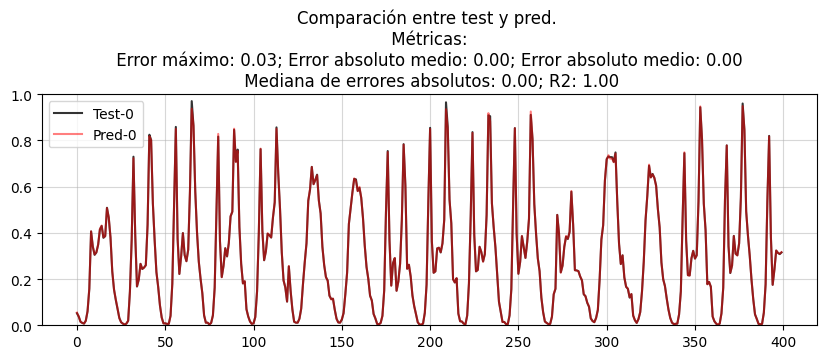

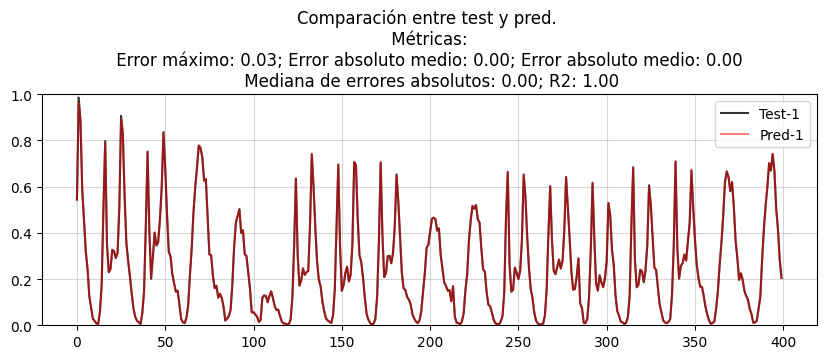

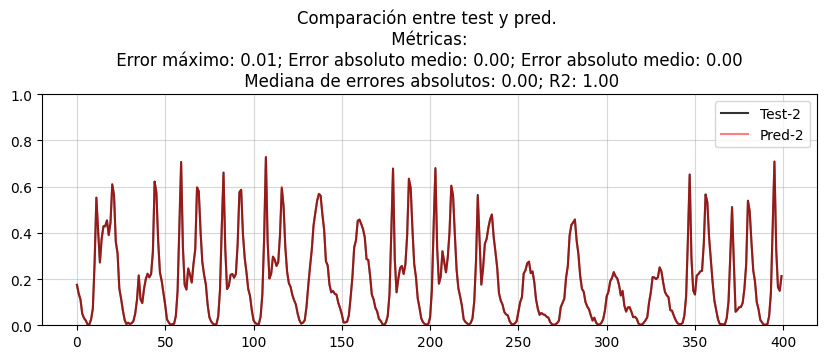

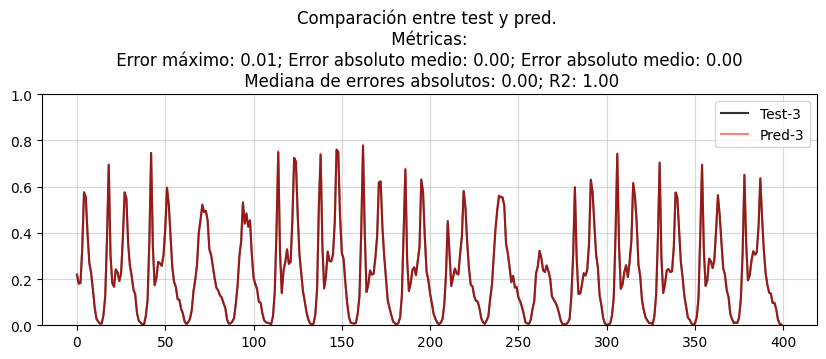

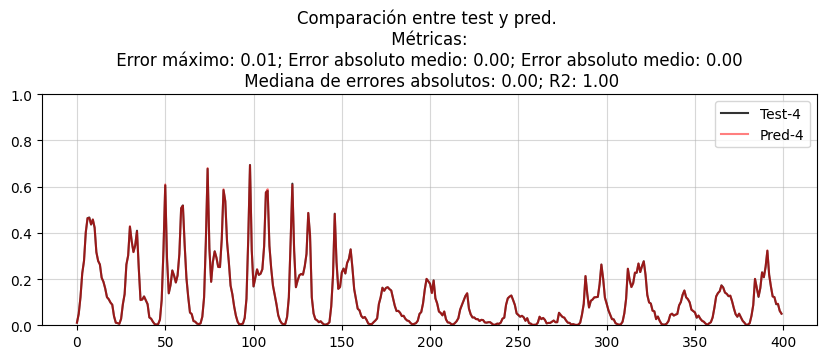

In [165]:
j=0
for joint in list(timeSplits.split(df)):
    # fig, ax = plt.subplots(figsize=(20,5), dpi=120)
    fig, ax = plt.subplots(figsize=(10,3), dpi=100)
    y.iloc[joint[1]].reset_index(drop=True).plot(ax=ax,label='Test-'+str(j), alpha=0.8, color='black')

    gbrt.fit(X.iloc[joint[0]], y.iloc[joint[0]])
    pd.DataFrame(gbrt.predict(X.iloc[joint[1]])).rename({0:'Pred-'+str(j)}, axis=1).plot(ax=ax, alpha=0.5, color='red')
    plt.legend()
    plt.title('Comparación entre test y pred. \n Métricas: \n Error máximo: '+f'{abs(max_errors[j]):.2f}'
             +'; Error absoluto medio: '+f'{abs(mean_absolute_errors[j]):.2f}'
             +'; Error absoluto medio: '+f'{abs(mean_absolute_errors[j]):.2f} \n'
             +' Mediana de errores absolutos: '+f'{abs(median_absolute_errors[j]):.2f}'
             +'; R2: '+f'{abs(r2s[j]):.2f}')
    plt.ylim(0,1)
    plt.grid(alpha=0.5)
    j+=1
    


Comentarios finales \
Consideremos R^2 > 0.8 como un buen fit.

- 0- R^2 = 0.94 es excelente. Hay un pico entre 250 y 300 que está sobreestimado y tiene un 39% de error. Este detalle particular ocurre en todos los gráficos, en algún pico. Se debe tener presente porque quizá el objetivo del trabajo sea tener mucho cuidado con tales extremos. 
- 1- R^2 = 0.82 es muy bueno. Tiene errores máximos y porcentuales mayores al anterior, por eso disminuye R^2. 
- 2- R^2 = 0.68 es un ajuste regular tendiendo a malo. Similarmente a 1, hay máximos en torno a 250 y 300 o 350 que son muy mal ajustados. 
- 3- R^2 = 0.91 es excelente, como el gráfico 1, solo que no se observa ningún pico fuera de control.
- 4- R^2 = 0.34 es inaceptable. Nuevamente, la zona en torno a 250 es defectuosa en cuanto al ajuste. \

- Observación general: aquellos gráficos donde el número de counts/counts_max es ~<0.6 el ajuste suele ser entre regular y malo. Tal vez deberían generarse distintos modelos en función del valor de counts/counts_max.